In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from geometry import *
from event_detector import *
from features_extractor import *
from tennis_metrics import *

CSV_FOLDER = Path(r"D:\desk\Results_Mediapipe\data_csv")

all_files = sorted(list(CSV_FOLDER.glob('*.csv')))

print(f"There are {len(all_files)} files.")

In [ ]:
kick_platform  = [f for f in all_files if 'kick' in f.name.lower() and 'platform' in f.name.lower()][:16]
kick_pinpoint  = [f for f in all_files if 'kick' in f.name.lower() and 'pinpoint' in f.name.lower()][:16]

slice_platform = [f for f in all_files if 'slice' in f.name.lower() and 'platform' in f.name.lower()][:16]
slice_pinpoint = [f for f in all_files if 'slice' in f.name.lower() and 'pinpoint' in f.name.lower()][:16]

flat_platform  = [f for f in all_files if 'flat' in f.name.lower() and 'platform' in f.name.lower()][:16]
flat_pinpoint  = [f for f in all_files if 'flat' in f.name.lower() and 'pinpoint' in f.name.lower()][:16]

kick_files  = kick_platform  + kick_pinpoint
slice_files = slice_platform + slice_pinpoint
flat_files  = flat_platform  + flat_pinpoint

selected_files = kick_files + slice_files + flat_files
len(selected_files)

# VAMOS A ANALIZAR LAS MÉTRICAS

*MÉTRICA 1: Observamos el salto entre los diferentes efectos*

In [ ]:
flat_jumps  = []
kick_jumps  = []
slice_jumps = []

for f in flat_files:
    df = pd.read_csv(f)
    start_f, min_f, max_f, target_f, _ = calculate_knee_frames(df)
    hip_width = get_hip_width(df, start_f)
    flat_jumps.append(calculate_max_jump(df, start_f, max_f, hip_width))

for f in kick_files:
    df = pd.read_csv(f)
    start_f, min_f, max_f, target_f, _ = calculate_knee_frames(df)
    hip_width = get_hip_width(df, start_f)
    kick_jumps.append(calculate_max_jump(df, start_f, max_f, hip_width))

for f in slice_files:
    df = pd.read_csv(f)
    start_f, min_f, max_f, target_f, _ = calculate_knee_frames(df)
    hip_width = get_hip_width(df, start_f)
    slice_jumps.append(calculate_max_jump(df, start_f, max_f, hip_width))

*VISUALIZATION*

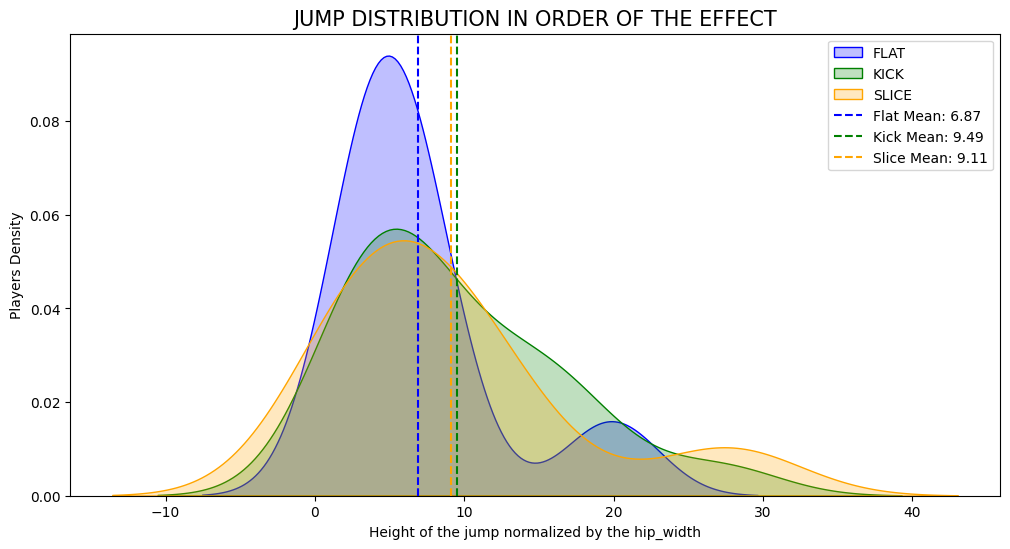

In [4]:
plt.figure(figsize=(12, 6))

# Histograms
sns.kdeplot(flat_jumps, fill=True, color="blue", label="FLAT", bw_adjust=1)
sns.kdeplot(kick_jumps, fill=True, color="green", label="KICK", bw_adjust=1)
sns.kdeplot(slice_jumps, fill=True, color="orange", label="SLICE", bw_adjust=1)

# We drawn the mean with vertical lines
plt.axvline(np.mean(flat_jumps), color='blue', linestyle='--', label=f'Flat Mean: {np.mean(flat_jumps):.2f}')
plt.axvline(np.mean(kick_jumps), color='green', linestyle='--', label=f'Kick Mean: {np.mean(kick_jumps):.2f}')
plt.axvline(np.mean(slice_jumps), color='orange', linestyle='--', label=f'Slice Mean: {np.mean(slice_jumps):.2f}')

plt.title("JUMP DISTRIBUTION IN ORDER OF THE EFFECT", fontsize=15)
plt.xlabel("Height of the jump normalized by the hip_width")
plt.ylabel("Players Density")
plt.legend()
plt.show()

*MÉTRICA 2: VAMOS A ANALIZAR LA MUÑECA RESPECTO A LA ESPALDA*

In [ ]:
def get_whip_from_file(file_path):
    try:
        df = pd.read_csv(file_path)
        _, min_f, max_f, _, _ = calculate_knee_frames(df)
        result = extract_impact_metrics(df, min_f, max_f)
        if result:
            return result['lateral_offset']
        return None
    except:
        return None

In [6]:
whip_flat = [get_whip_from_file(f) for f in flat_files]
whip_kick = [get_whip_from_file(f) for f in kick_files]
whip_slice = [get_whip_from_file(f) for f in slice_files]

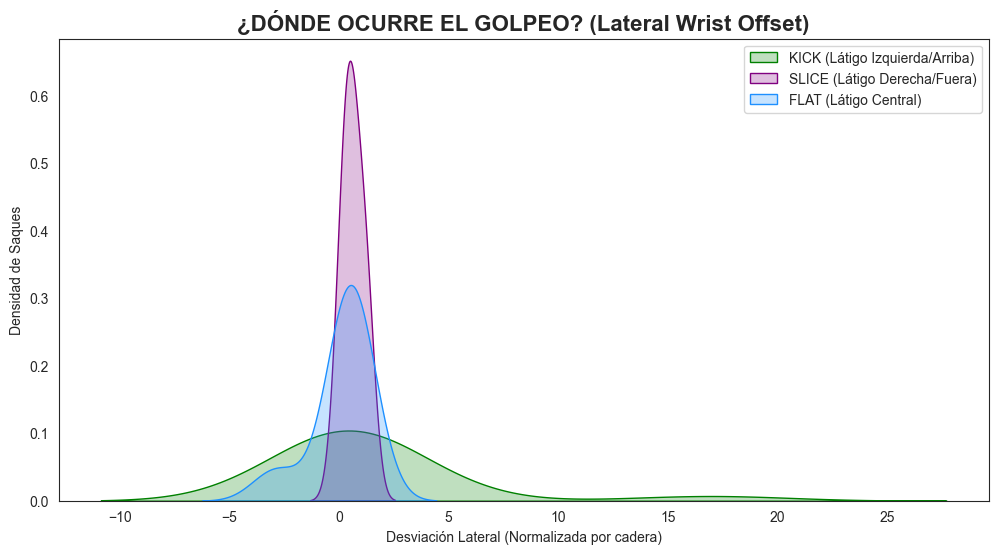

In [7]:
plt.figure(figsize=(12, 6))
sns.set_style("white")

sns.kdeplot(whip_kick, fill=True, color="green", label="KICK (Látigo Izquierda/Arriba)", bw_adjust=1.5)
sns.kdeplot(whip_slice, fill=True, color="purple", label="SLICE (Látigo Derecha/Fuera)", bw_adjust=1.5)
sns.kdeplot(whip_flat, fill=True, color="dodgerblue", label="FLAT (Látigo Central)", bw_adjust=1.5)

plt.title("¿DÓNDE OCURRE EL GOLPEO? (Lateral Wrist Offset)", fontsize=16, fontweight='bold')
plt.xlabel("Desviación Lateral (Normalizada por cadera)")
plt.ylabel("Densidad de Saques")
plt.legend()
plt.show()

*MÉTRICA 3: VAMOS A ANALIZAR EL ÁNGULO DE CADERA RESPECTO AL PUNTO DE CARGA DE LA RODILLA*

In [ ]:
def collect_tilt_metrics(file_list):
    results = []
    for f in file_list:
        df = pd.read_csv(f)
        _, _, _, target_f, _ = calculate_knee_frames(df)
        tilt = get_hip_tilt_data(df, target_f)
        results.append(tilt)
    return results

In [17]:
data_flat = collect_tilt_metrics(flat_files)
data_kick = collect_tilt_metrics(kick_files)
data_slice = collect_tilt_metrics(slice_files)

In [ ]:
print(f"Datos FLAT ({len(data_flat)}): {data_flat}")
print(f"Datos KICK ({len(data_kick)}): {data_kick}")
print(f"Datos SLICE ({len(data_slice)}): {data_slice}")

Datos FLAT (16): [0.5576366618186009, 0.7630062528799372, 0.9999970067974006, 0.5568963927705756, 0.33634831436543616, 0.7762452105916444, 0.9159186860395507, 0.44370272162047775, 0.9999843698221963, 0.6861473359353993, 0.5854568922949035, 0.09289746939925066, 0.8439413137644706, 0.6288758596039017, 0.48593895756642497, 0.24750247372373252]
Datos KICK (16): [0.08575861850336125, 0.24295834044321366, 0.7804556699438945, 0.5349107578682523, 0.14918951506591624, 0.867422649756771, 0.7574613300435947, 0.19138382456829253, 0.1446703675552442, 0.3600749850964724, 0.21308519373216778, 0.5329584527079703, 0.25150518142113243, 0.0228852810386827, 0.2810201851183387, 0.30678440885182084]
Datos SLICE (16): [0.41042642889791947, 0.07830035083420982, 0.8380958173293215, 0.07971550364589305, 0.10230695825043302, 0.23041760198188413, 0.3984624782639771, 0.7311357316419284, 0.5478267060537253, 0.21251504781777436, 0.33544838382637426, 0.9294828140839333, 0.8864383622169506, 0.9999851780314377, 0.36424

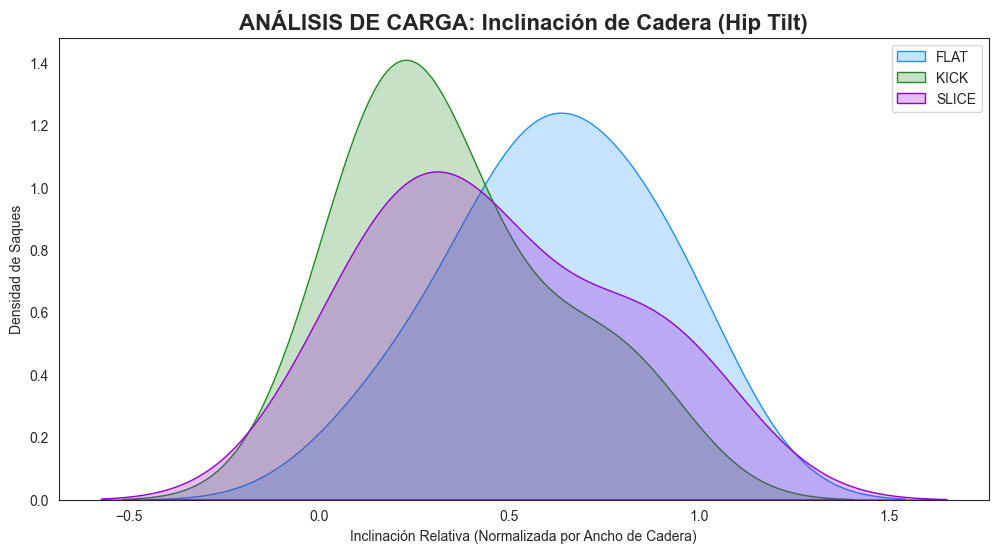

In [19]:
plt.figure(figsize=(12, 6))
sns.set_style("white")

sns.kdeplot(data_flat, fill=True, color="dodgerblue", label="FLAT", bw_adjust=1.2)
sns.kdeplot(data_kick, fill=True, color="forestgreen", label="KICK", bw_adjust=1.2)
sns.kdeplot(data_slice, fill=True, color="darkviolet", label="SLICE", bw_adjust=1.2)

plt.title("ANÁLISIS DE CARGA: Inclinación de Cadera (Hip Tilt)", fontsize=16, fontweight='bold')
plt.xlabel("Inclinación Relativa (Normalizada por Ancho de Cadera)")
plt.ylabel("Densidad de Saques")
plt.legend()
plt.show()